In [1]:
import sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [2]:
sys.path.append("/home/alexis/Documents/COMP558/COMP558-FinalProject/code/")
# sys.path.append("/workspaces/python-opencv/repo/code/")

In [3]:
from tracker import Tracker
from optical_flow.bounding_box import BoundingBox
from feature_detection.shi_tomasi import ShiTomasiDetector
from feature_description.orb_descriptor import ORBDescriptor
from optical_flow.lucas_kanade import LucasKanade
from segmentation.fuzzy_c_means import FuzzyCMeansSegmenter

ImportError: cannot import name 'BoundingBox' from partially initialized module 'optical_flow.bounding_box' (most likely due to a circular import) (/home/alexis/Documents/COMP558/COMP558-FinalProject/code/optical_flow/bounding_box.py)

In [4]:
video_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/VIDEO-20250113-190349.mp4"
depth_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/DEPTH-20250113-190349.mp4"

output_name = "out/complete5.mp4"

In [5]:
x, y, w, h = 275, 200, 110, 85

shi_tomasi_params = dict(params = dict( maxCorners = 1000, qualityLevel = 0.01, minDistance = 5, blockSize = 5))
# orb_params = {"params": {"nfeatures" : 1000, "edgeThreshold" : 15, "patchSize" : 10}}
orb_params = {"params": {"nfeatures" : 1000, "edgeThreshold" : 15, "patchSize" : 10}}
# gu_params = {"_lambda" : 4/5, "frame_buffer" : 60, "gamma" : 0.1, "gamma_fit" : 0.5, "gamma_area" : 0.1, "gamma_drift" : 0.5}
gu_params = {"_lambda" : 4/5, "frame_buffer" : 60, "gamma" : 0.1, "gamma_fit" : 1, "gamma_area" : 0.1, "gamma_drift" : 0.5}
lucas_kanade_params = {}
c_means_params = {"n_groups" : 1, "target_error" : 0, "neighbourhood_size" : 10, "m" : 2, "lambda_val" : 2, "max_iter" : 1}

In [6]:
initial_bbox = BoundingBox(x, y, w, h)

feature_detector = ShiTomasiDetector(**shi_tomasi_params)
feature_descriptor = ORBDescriptor(**orb_params)
optical_flow = LucasKanade(**lucas_kanade_params)
segmenter = FuzzyCMeansSegmenter(**c_means_params)

In [7]:
cap_video = cv.VideoCapture(video_name)
cap_depth = cv.VideoCapture(depth_name)

ret_video, frame_video = cap_video.read()
ret_depth, frame_depth = cap_depth.read()

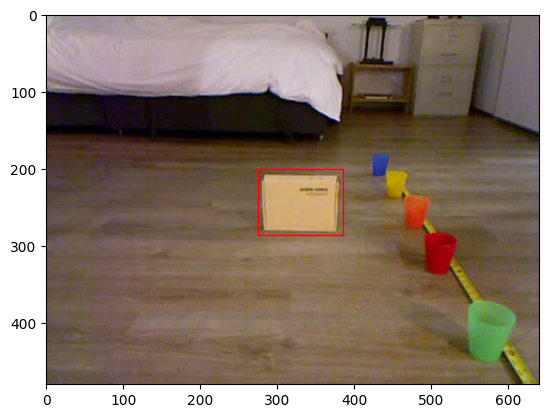

In [8]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [9]:
tracker = Tracker(frame_video, initial_bbox, feature_detector, optical_flow, feature_descriptor, segmenter, gu_params)

DroTrackBBOXStats(scale=0.17708333333333334, delta=(1, -2))


In [10]:
fps = cap_video.get(cv.CAP_PROP_FPS)

fourcc = cv.VideoWriter_fourcc(*'mp4v')
video_writer = cv.VideoWriter(output_name, fourcc, fps, frame_video.shape[:-1][::-1])

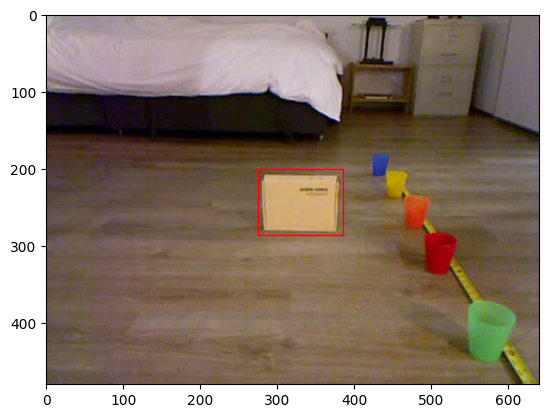

In [11]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

BoundingBox(x=np.float32(279.0), y=np.float32(209.0), w=np.float32(101.0), h=np.float32(71.0))
BoundingBox(x=275, y=200, w=110, h=85)


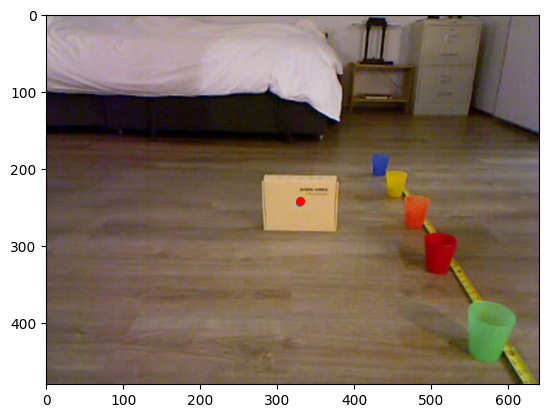

In [12]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])
from optical_flow.bounding_box import points_to_bbox
from optical_flow.bounding_box import points_clean_up

# coord = np.mean(tracker.points, axis = 0)
coord = points_to_bbox(points_clean_up(tracker.points))

circ = patches.Circle((coord.cx, coord.cy))
print(coord)
ax.add_patch(circ)

circ2 = patches.Circle((initial_bbox.cx, initial_bbox.cy), color="r")
print(initial_bbox)
ax.add_patch(circ2)

plt.show()

In [13]:
length = int(cap_video.get(cv.CAP_PROP_FRAME_COUNT))

for i in tqdm(range(length)):

    if not (ret_video and ret_depth):
        break

    bbox = tracker.track(frame_video)

    img2 = cv.rectangle(frame_video, (bbox.x, bbox.y), (bbox.x + bbox.w, bbox.y + bbox.h), 255, 2)

    video_writer.write(img2)

    ret_video, frame_video = cap_video.read()
    ret_depth, frame_depth = cap_depth.read()

100%|██████████| 479/479 [05:08<00:00,  1.55it/s]


In [14]:
video_writer.release()

In [15]:
tracker.lk_errors

[array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([[1.991284 ],
        [1.7914541],
        [1.8619615],
        [2.3474348],
        [1.6538407],
        [1.8472222],
        [2.4182255],
        [2.1472507],
        [2.3199406],
        [2.0975056],
        [2.5149517],
        [1.6197562],
        [2.5729876],
        [2.0992064]], dtype=float32),
 array([[1.7014598],
        [1.4949688],
        [2.1699264],
        [1.9894416],
        [1.6882795],
        [1.5726333],
        [2.0385487],
        [2.2238522],
        [1.9036281],
        [1.884708 ],
        [2.2011764],
        [1.8193736],
        [1.8881094],
        [1.9158872]], dtype=float32),
 array([[1.4579791],
        [1.6428572],
        [1.6016157],
        [1.5960176],
        [1.6781462],
        [1.2541808],
        [1.5880811],
        [1.8633786